In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 1 — Install/Import Required Libraries

In [70]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    pearsonr,
    norm,
    poisson
)

import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — Set Your Dataset Path

In [71]:

import os

PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project_older"

print("Project path:")
print(PROJECT_PATH)

if os.path.exists(PROJECT_PATH):
    print("\n✅ Project folder found!")
    print("\nContents:")

    for item in os.listdir(PROJECT_PATH):
        print(" -", item)
else:
    print("\n❌ Project folder not found.")

Project path:
/content/drive/MyDrive/ADS-Airbnb-Project_older

✅ Project folder found!

Contents:
 - .dvcignore
 - .gitignore
 - Coverpage.pdf
 - Coverpage.docx
 - B2_ADS_Assignment_Result.pdf
 - assignment1quiz.png
 - deployment
 - notebooks
 - outputs
 - .dvc
 - .git
 - Assignment Results
 - datasets
 - GRP2_DOCS
 - Exp8


STEP 3 — Load the Feature-Engineered Datasets
Cell 3.1 — Set the paths

In [72]:

import os
import pandas as pd
import numpy as np

PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project_older"

DATASETS_PATH = os.path.join(
    PROJECT_PATH,
    "datasets"
)

PROCESSED_DATA_PATH = os.path.join(
    DATASETS_PATH,
    "processed"
)

print("Project Path:")
print(PROJECT_PATH)

print("\nProcessed Data Path:")
print(PROCESSED_DATA_PATH)

print("\nFiles available:")
for file in os.listdir(PROCESSED_DATA_PATH):
    print(" -", file)

Project Path:
/content/drive/MyDrive/ADS-Airbnb-Project_older

Processed Data Path:
/content/drive/MyDrive/ADS-Airbnb-Project_older/datasets/processed

Files available:
 - listings_cleaned.csv
 - reviews_cleaned.csv
 - calendar_cleaned.csv
 - listings_feature_engineered.csv
 - calendar_feature_engineered.csv
 - reviews_feature_engineered.csv
 - merged_dataset.csv
 - experiment_3_eda_dataset.csv


STEP 3.2 — Load Listings

In [73]:


listings_file = os.path.join(
    PROCESSED_DATA_PATH,
    "listings_feature_engineered.csv"
)

listings_df = pd.read_csv(listings_file)

print("Listings dataset loaded successfully!")
print("Shape:", listings_df.shape)

display(listings_df.head())

Listings dataset loaded successfully!
Shape: (490, 101)


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenity_count,availability_ratio,is_entire_home,is_superhost,bathroom_bedroom_ratio,is_instant_bookable,average_review_score,host_experience_years,profile_pic_verified,identity_verified,host_verification_score
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,5,13,4,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Essentials"", ""Heating"", ""Wifi"", ""...",$80.43,2027-03-31,2027-04-28,2252.0,80.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",28.0,1125.0,28.0,28.0,1125.0,1125.0,28.0,1125.0,NaN,t,0,0,0,77,2026-06-16,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06,8,0.210959,1,0,0.5,NaN,3.778333,NaN,1,1,2
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,10,11,10,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Microwave"", ""S...",$211.00,2026-07-20,2026-07-21,211.0,211.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,1125.0,1.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,23,53,328,2026-06-16,317,8,0,162,9,48,10128.0,2014-08-15,2026-01-25,4.75,4.88,4.87,4.85,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20,33,0.898630,1,1,1.0,NaN,4.835000,NaN,1,1,2
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with

STEP 3.3 — Load Calendar

In [74]:

calendar_file = os.path.join(
    PROCESSED_DATA_PATH,
    "calendar_feature_engineered.csv"
)

calendar_df = pd.read_csv(calendar_file)

print("Calendar dataset loaded successfully!")
print("Shape:", calendar_df.shape)

display(calendar_df.head())

Calendar dataset loaded successfully!
Shape: (490, 6)


,listing_id,calendar_availability_rate,calendar_available_days,calendar_avg_minimum_nights,calendar_avg_maximum_nights,calendar_observation_count
0,2992450,NaN,0.0,28.000000,1125.0,365
1,3820211,NaN,0.0,2.728767,1125.0,365
2,5651579,NaN,0.0,1.284932,1125.0,365
3,6623339,NaN,0.0,2.728767,1125.0,365
4,9501054,NaN,0.0,1.000000,1125.0,365


STEP 3.4 — Load Reviews

In [75]:


reviews_file = os.path.join(
    PROCESSED_DATA_PATH,
    "reviews_feature_engineered.csv"
)

reviews_df = pd.read_csv(reviews_file)

print("Reviews dataset loaded successfully!")
print("Shape:", reviews_df.shape)

display(reviews_df.head())

Reviews dataset loaded successfully!
Shape: (430, 6)


,listing_id,review_count,review_period_days,days_since_last_review,reviews_per_month_est,recent_review_count
0,2992450,9,2969,1399,0.0,0.0
1,3820211,317,4181,142,0.0,8.0
2,5651579,406,4053,4,0.0,37.0
3,6623339,332,3676,351,0.0,1.0
4,9501054,469,3780,7,0.0,47.0


STEP 4 — Verify All Three Datasets

In [76]:

print("=" * 70)
print("EXPERIMENT 3 — DATASET OVERVIEW")
print("=" * 70)

print("\nListings Dataset")
print("Rows:", listings_df.shape[0])
print("Columns:", listings_df.shape[1])

print("\nCalendar Dataset")
print("Rows:", calendar_df.shape[0])
print("Columns:", calendar_df.shape[1])

print("\nReviews Dataset")
print("Rows:", reviews_df.shape[0])
print("Columns:", reviews_df.shape[1])

EXPERIMENT 3 — DATASET OVERVIEW

Listings Dataset
Rows: 490
Columns: 101

Calendar Dataset
Rows: 490
Columns: 6

Reviews Dataset
Rows: 430
Columns: 6


STEP 5 — Check the ID Column

In [77]:

print("Listings ID columns:")
print(
    [col for col in listings_df.columns
     if "id" in col.lower()]
)

print("\nCalendar ID columns:")
print(
    [col for col in calendar_df.columns
     if "id" in col.lower()]
)

print("\nReviews ID columns:")
print(
    [col for col in reviews_df.columns
     if "id" in col.lower()]
)

Listings ID columns:
['listing_id', 'scrape_id', 'host_id', 'host_profile_id', 'host_identity_verified', 'identity_verified']

Calendar ID columns:
['listing_id']

Reviews ID columns:
['listing_id']


STEP 6 — Check for Duplicate Listing IDs

In [78]:
# ============================================
# STEP 8 — CHECK DUPLICATES
# ============================================

print("LISTINGS")
print("Rows:", len(listings_df))
print("Unique IDs:", listings_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    listings_df["listing_id"].duplicated().sum()
)

print("\nCALENDAR")
print("Rows:", len(calendar_df))
print("Unique IDs:", calendar_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    calendar_df["listing_id"].duplicated().sum()
)

print("\nREVIEWS")
print("Rows:", len(reviews_df))
print("Unique IDs:", reviews_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    reviews_df["listing_id"].duplicated().sum()
)

LISTINGS
Rows: 490
Unique IDs: 490
Duplicate IDs: 0

CALENDAR
Rows: 490
Unique IDs: 490
Duplicate IDs: 0

REVIEWS
Rows: 430
Unique IDs: 430
Duplicate IDs: 0


In [79]:
print("LISTINGS")
print("Rows:", len(listings_df))
print("Unique IDs:", listings_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    listings_df["listing_id"].duplicated().sum()
)

print("\nCALENDAR")
print("Rows:", len(calendar_df))
print("Unique IDs:", calendar_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    calendar_df["listing_id"].duplicated().sum()
)

print("\nREVIEWS")
print("Rows:", len(reviews_df))
print("Unique IDs:", reviews_df["listing_id"].nunique())
print(
    "Duplicate IDs:",
    reviews_df["listing_id"].duplicated().sum()
)

LISTINGS
Rows: 490
Unique IDs: 490
Duplicate IDs: 0

CALENDAR
Rows: 490
Unique IDs: 490
Duplicate IDs: 0

REVIEWS
Rows: 430
Unique IDs: 430
Duplicate IDs: 0


STEP 7 — Create Listing-Level Calendar Dataset

In [80]:

calendar_agg = (
    calendar_df
    .groupby("listing_id")
    .agg(
        calendar_availability_rate=(
            "calendar_availability_rate",
            "mean"
        ),
        calendar_available_days=(
            "calendar_available_days",
            "mean"
        ),
        calendar_avg_minimum_nights=(
            "calendar_avg_minimum_nights",
            "mean"
        ),
        calendar_avg_maximum_nights=(
            "calendar_avg_maximum_nights",
            "mean"
        ),
        calendar_observation_count=(
            "calendar_observation_count",
            "mean"
        )
    )
    .reset_index()
)

print("Aggregated Calendar dataset:")
print("Shape:", calendar_agg.shape)

display(calendar_agg.head())

Aggregated Calendar dataset:
Shape: (490, 6)


,listing_id,calendar_availability_rate,calendar_available_days,calendar_avg_minimum_nights,calendar_avg_maximum_nights,calendar_observation_count
0,2992450,NaN,0.0,28.000000,1125.0,365.0
1,3820211,NaN,0.0,2.728767,1125.0,365.0
2,5651579,NaN,0.0,1.284932,1125.0,365.0
3,6623339,NaN,0.0,2.728767,1125.0,365.0
4,9501054,NaN,0.0,1.000000,1125.0,365.0


STEP 8 — Create Listing-Level Reviews Dataset

In [81]:

reviews_agg = (
    reviews_df
    .groupby("listing_id")
    .agg(
        review_count=("review_count", "max"),
        review_period_days=("review_period_days", "max"),
        days_since_last_review=("days_since_last_review", "min"),
        reviews_per_month_est=("reviews_per_month_est", "max"),
        recent_review_count=("recent_review_count", "max")
    )
    .reset_index()
)

print("Aggregated Reviews dataset:")
print("Shape:", reviews_agg.shape)

display(reviews_agg.head())

Aggregated Reviews dataset:
Shape: (430, 6)


,listing_id,review_count,review_period_days,days_since_last_review,reviews_per_month_est,recent_review_count
0,2992450,9,2969,1399,0.0,0.0
1,3820211,317,4181,142,0.0,8.0
2,5651579,406,4053,4,0.0,37.0
3,6623339,332,3676,351,0.0,1.0
4,9501054,469,3780,7,0.0,47.0


STEP 9 — Merge the Three Datasets

In [82]:

eda_df = listings_df.merge(
    calendar_agg,
    on="listing_id",
    how="left"
)

eda_df = eda_df.merge(
    reviews_agg,
    on="listing_id",
    how="left"
)

print("=" * 70)
print("FINAL EDA DATASET")
print("=" * 70)

print("Shape:", eda_df.shape)

display(eda_df.head())

FINAL EDA DATASET
Shape: (490, 111)


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenity_count,availability_ratio,is_entire_home,is_superhost,bathroom_bedroom_ratio,is_instant_bookable,average_review_score,host_experience_years,profile_pic_verified,identity_verified,host_verification_score,calendar_availability_rate,calendar_available_days,calendar_avg_minimum_nights,calendar_avg_maximum_nights,calendar_observation_count,review_count,review_period_days,days_since_last_review,reviews_per_month_est,recent_review_count
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,5,13,4,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Essentials"", ""Heating"", ""Wifi"", ""...",$80.43,2027-03-31,2027-04-28,2252.0,80.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",28.0,1125.0,28.0,28.0,1125.0,1125.0,28.0,1125.0,NaN,t,0,0,0,77,2026-06-16,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06,8,0.210959,1,0,0.5,NaN,3.778333,NaN,1,1,2,NaN,0.0,28.000000,1125.0,365.0,9.0,2969.0,1399.0,0.0,0.0
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,10,11,10,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Microwave"", ""S...",$211.00,2026-07-20,2026-07-21,211.0,211.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,1125.0,1.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,23,53,328,2026-06-16,317,8,

STEP 10 — Verify the Merge

In [83]:
print("Total rows:", len(eda_df))

print(
    "Unique listing IDs:",
    eda_df["listing_id"].nunique()
)

print(
    "Duplicate listing IDs:",
    eda_df["listing_id"].duplicated().sum()
)

Total rows: 490
Unique listing IDs: 490
Duplicate listing IDs: 0


STEP 11 — Check the Final Features

In [84]:
print("FINAL EDA FEATURES")
print("=" * 70)

for i, column in enumerate(eda_df.columns, start=1):
    print(f"{i}. {column}")

FINAL EDA FEATURES
1. listing_id
2. listing_url
3. scrape_id
4. last_scraped
5. source
6. name
7. description
8. neighborhood_overview
9. picture_url
10. host_id
11. host_url
12. host_profile_id
13. host_profile_url
14. host_name
15. host_since
16. hosts_time_as_user_years
17. hosts_time_as_user_months
18. hosts_time_as_host_years
19. hosts_time_as_host_months
20. host_location
21. host_about
22. host_response_time
23. host_response_rate
24. host_acceptance_rate
25. host_is_superhost
26. host_thumbnail_url
27. host_picture_url
28. host_neighbourhood
29. host_listings_count
30. host_total_listings_count
31. host_verifications
32. host_has_profile_pic
33. host_identity_verified
34. neighbourhood
35. neighbourhood_cleansed
36. neighbourhood_group_cleansed
37. latitude
38. longitude
39. property_type
40. room_type
41. accommodates
42. bathrooms
43. bathrooms_text
44. bedrooms
45. beds
46. amenities
47. price
48. price_quote_checkin_date
49. price_quote_checkout_date
50. price_quote_total_p

STEP 12 — Descriptive Statistics

In [85]:
numeric_columns = eda_df.select_dtypes(
    include=np.number
).columns

descriptive_stats = (
    eda_df[numeric_columns]
    .describe()
    .T
)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
listing_id,490.0,9.617549e+17,5.800837e+17,2.992450e+06,6.904915e+17,1.112067e+18,1.458295e+18,1.701483e+18
scrape_id,490.0,2.026062e+13,0.000000e+00,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,490.0,6.840569e+15,1.069623e+17,6.490680e+05,4.762598e+07,2.329679e+08,4.667901e+08,1.676923e+18
host_profile_id,490.0,1.472998e+18,2.819249e+16,1.462518e+18,1.463574e+18,1.468232e+18,1.469754e+18,1.676923e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,490.0,6.751020e+00,3.623832e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.500000e+01
hosts_time_as_user_months,490.0,6.177551e+00,3.711903e+00,0.000000e+00,3.000000e+00,6.000000e+00,1.000000e+01,1.100000e+01
hosts_time_as_host_years,490.0,4.240816e+00,3.062934e+00,0.000000e+00,2.000000e+00,4.000000e+00,7.000000e+00,1.300000e+01
hosts_time_as_host_months,490.0,6.240816e+00,3.585241e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.100000e+01


STEP 13 — Create the Class Variable

In [86]:
review_median = eda_df["review_count"].median()

eda_df["review_activity_class"] = np.where(
    eda_df["review_count"] >= review_median,
    "High Review Activity",
    "Low Review Activity"
)

print("Median Review Count:", review_median)

print("\nClass Distribution:")
print(
    eda_df["review_activity_class"]
    .value_counts()
)

Median Review Count: 24.0

Class Distribution:
review_activity_class
Low Review Activity     273
High Review Activity    217
Name: count, dtype: int64


STEP 15 — Class Balance Plot

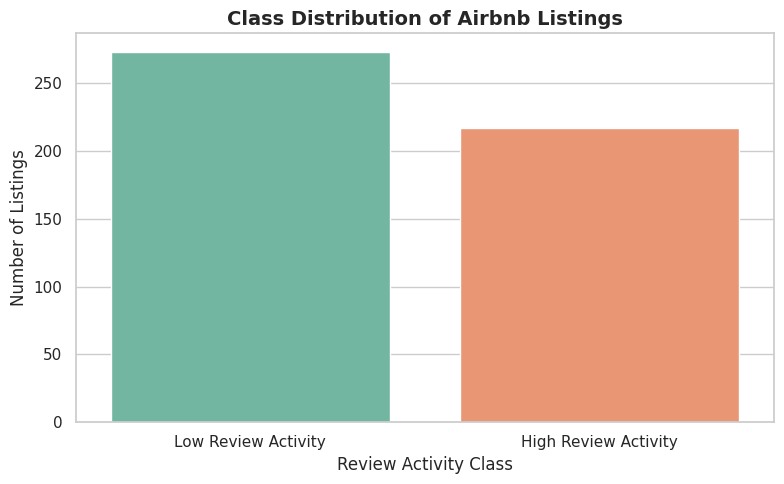

In [87]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="review_activity_class",
    hue="review_activity_class",
    palette="Set2",
    legend=False
)

plt.title(
    "Class Distribution of Airbnb Listings",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Review Activity Class")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

STEP 15 — Histograms

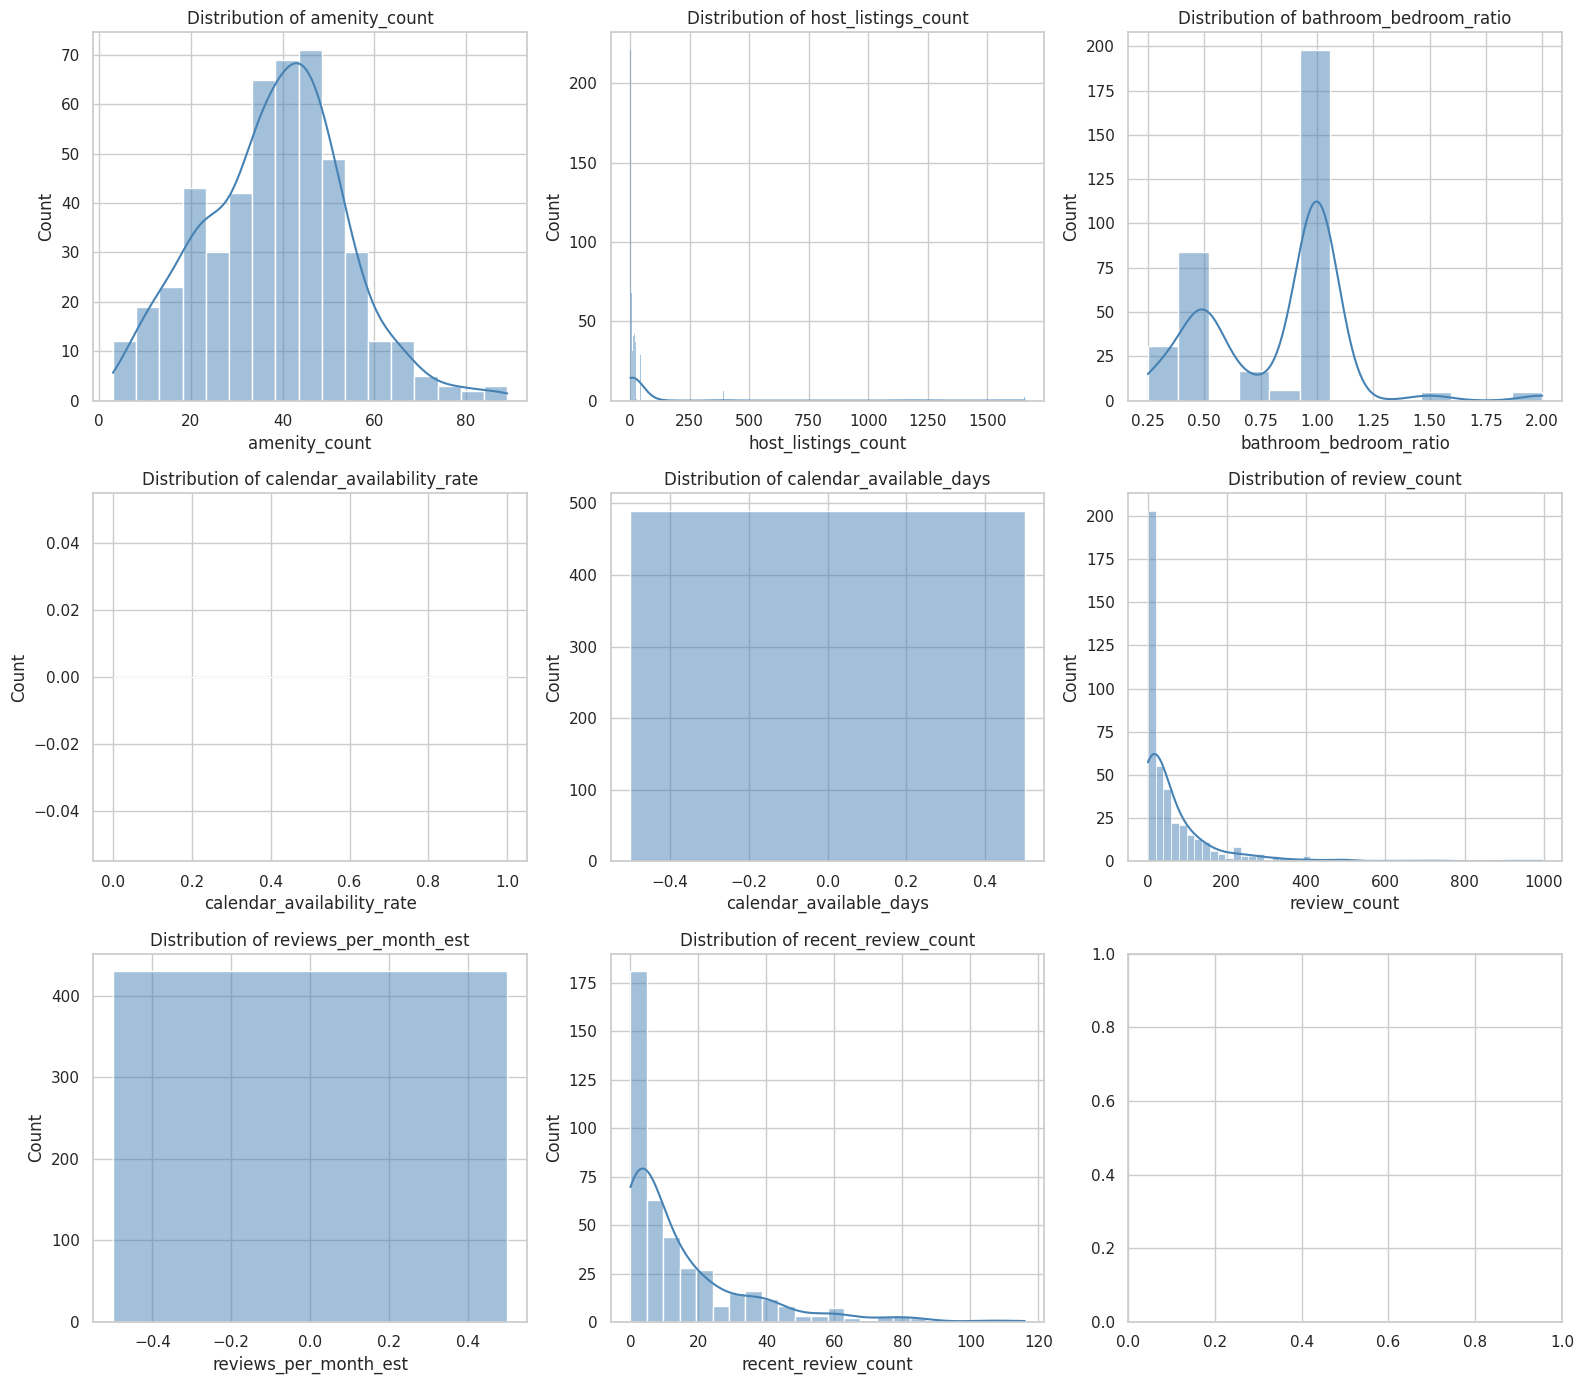

In [88]:
hist_features = [
    "amenity_count",
    "host_listings_count",
    "bathroom_bedroom_ratio",
    "calendar_availability_rate",
    "calendar_available_days",
    "review_count",
    "reviews_per_month_est",
    "recent_review_count"
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, feature in enumerate(hist_features):

    sns.histplot(
        data=eda_df,
        x=feature,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(
        f"Distribution of {feature}"
    )

plt.tight_layout()
plt.show()

STEP 16 — Boxplots

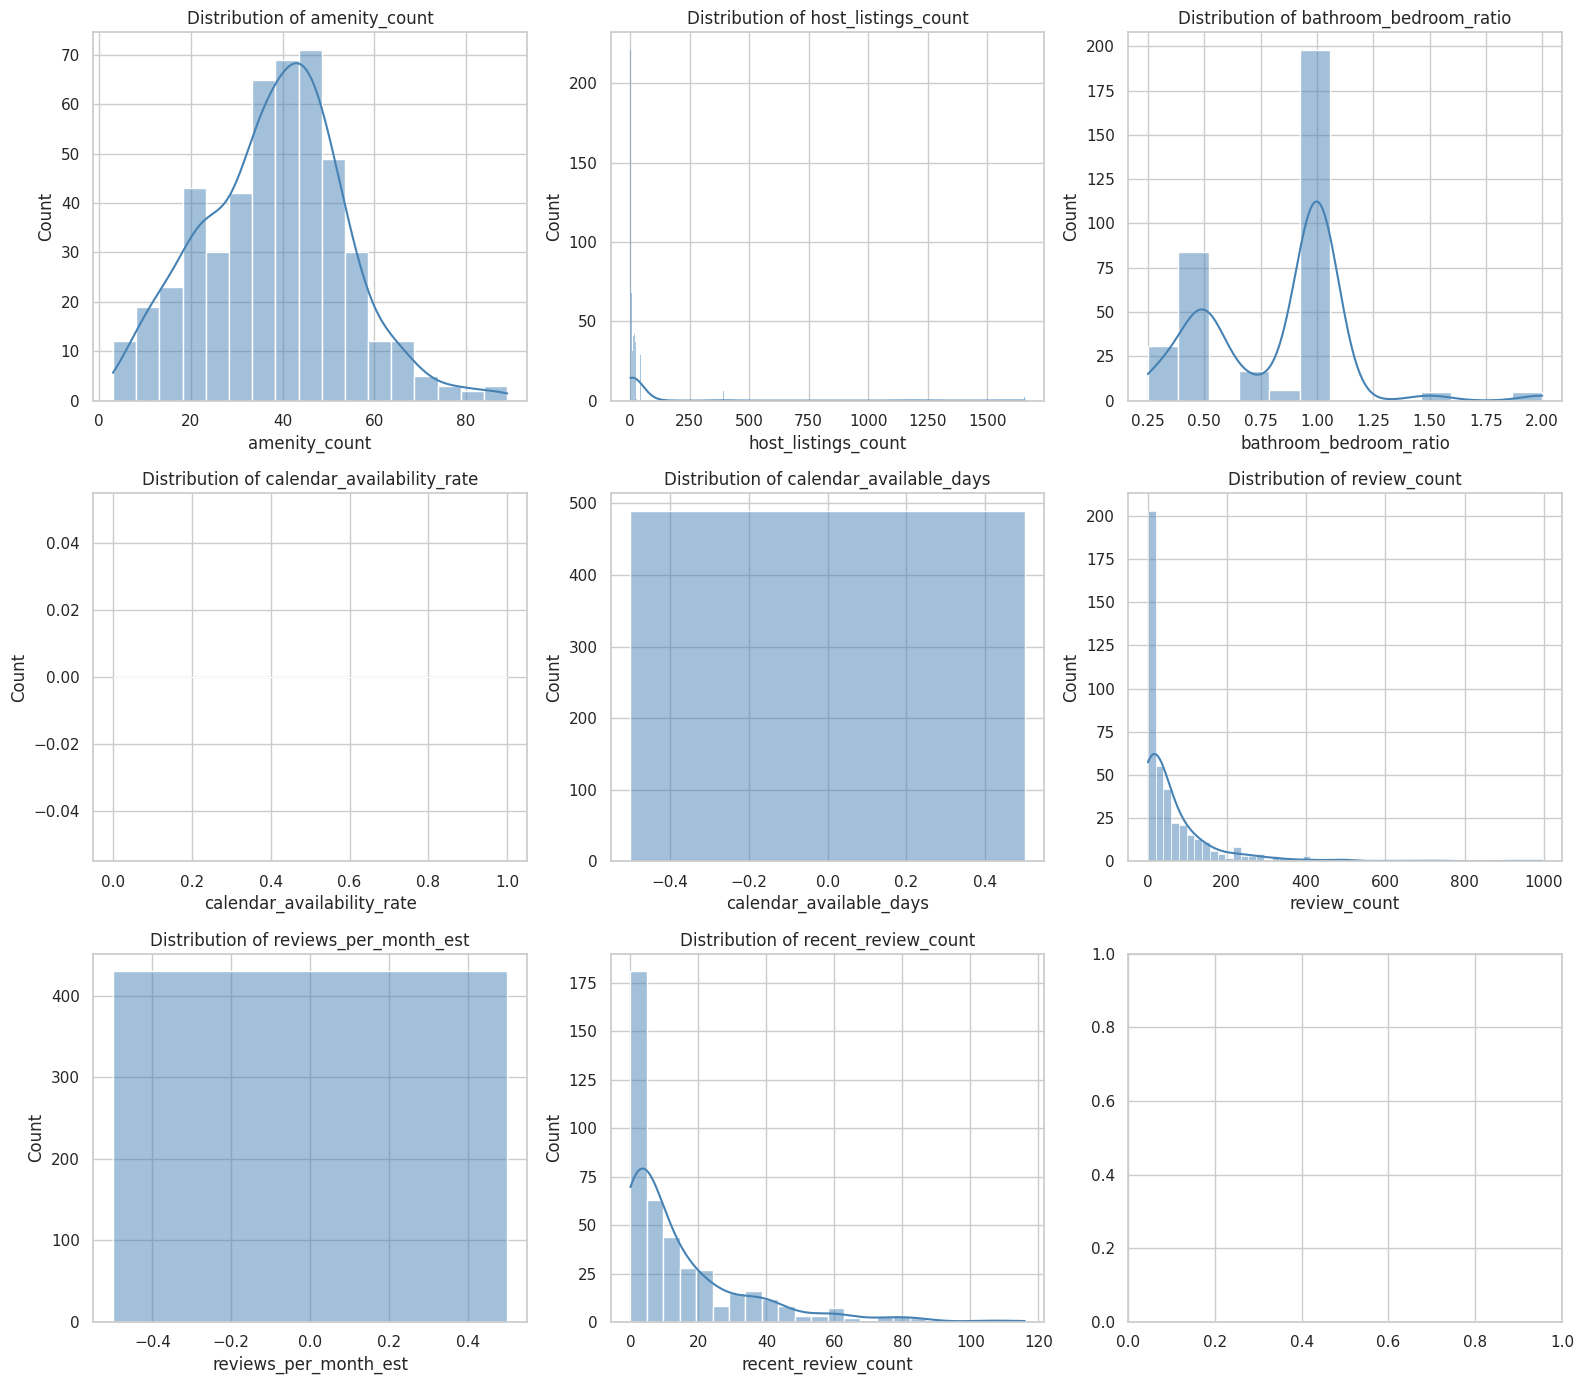

In [89]:
hist_features = [
    "amenity_count",
    "host_listings_count",
    "bathroom_bedroom_ratio",
    "calendar_availability_rate",
    "calendar_available_days",
    "review_count",
    "reviews_per_month_est",
    "recent_review_count"
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, feature in enumerate(hist_features):

    sns.histplot(
        data=eda_df,
        x=feature,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(
        f"Distribution of {feature}"
    )

plt.tight_layout()
plt.show()

STEP 17 — IQR Outlier Detection

In [90]:
outlier_summary = []

for feature in hist_features:

    Q1 = eda_df[feature].quantile(0.25)
    Q3 = eda_df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = eda_df[
        (eda_df[feature] < lower_bound) |
        (eda_df[feature] > upper_bound)
    ].shape[0]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,amenity_count,28.0,48.00,20.00,-2.000,78.000,5
1,host_listings_count,2.0,16.00,14.00,-19.000,37.000,49
2,bathroom_bedroom_ratio,0.5,1.00,0.50,-0.250,1.750,5
3,calendar_availability_rate,NaN,NaN,NaN,NaN,NaN,0
4,calendar_available_days,0.0,0.00,0.00,0.000,0.000,0
5,review_count,5.0,79.75,74.75,-107.125,191.875,39
6,reviews_per_month_est,0.0,0.00,0.00,0.000,0.000,0
7,recent_review_count,2.0,21.00,19.00,-26.500,49.500,28


STEP 18 — Correlation Heatmap

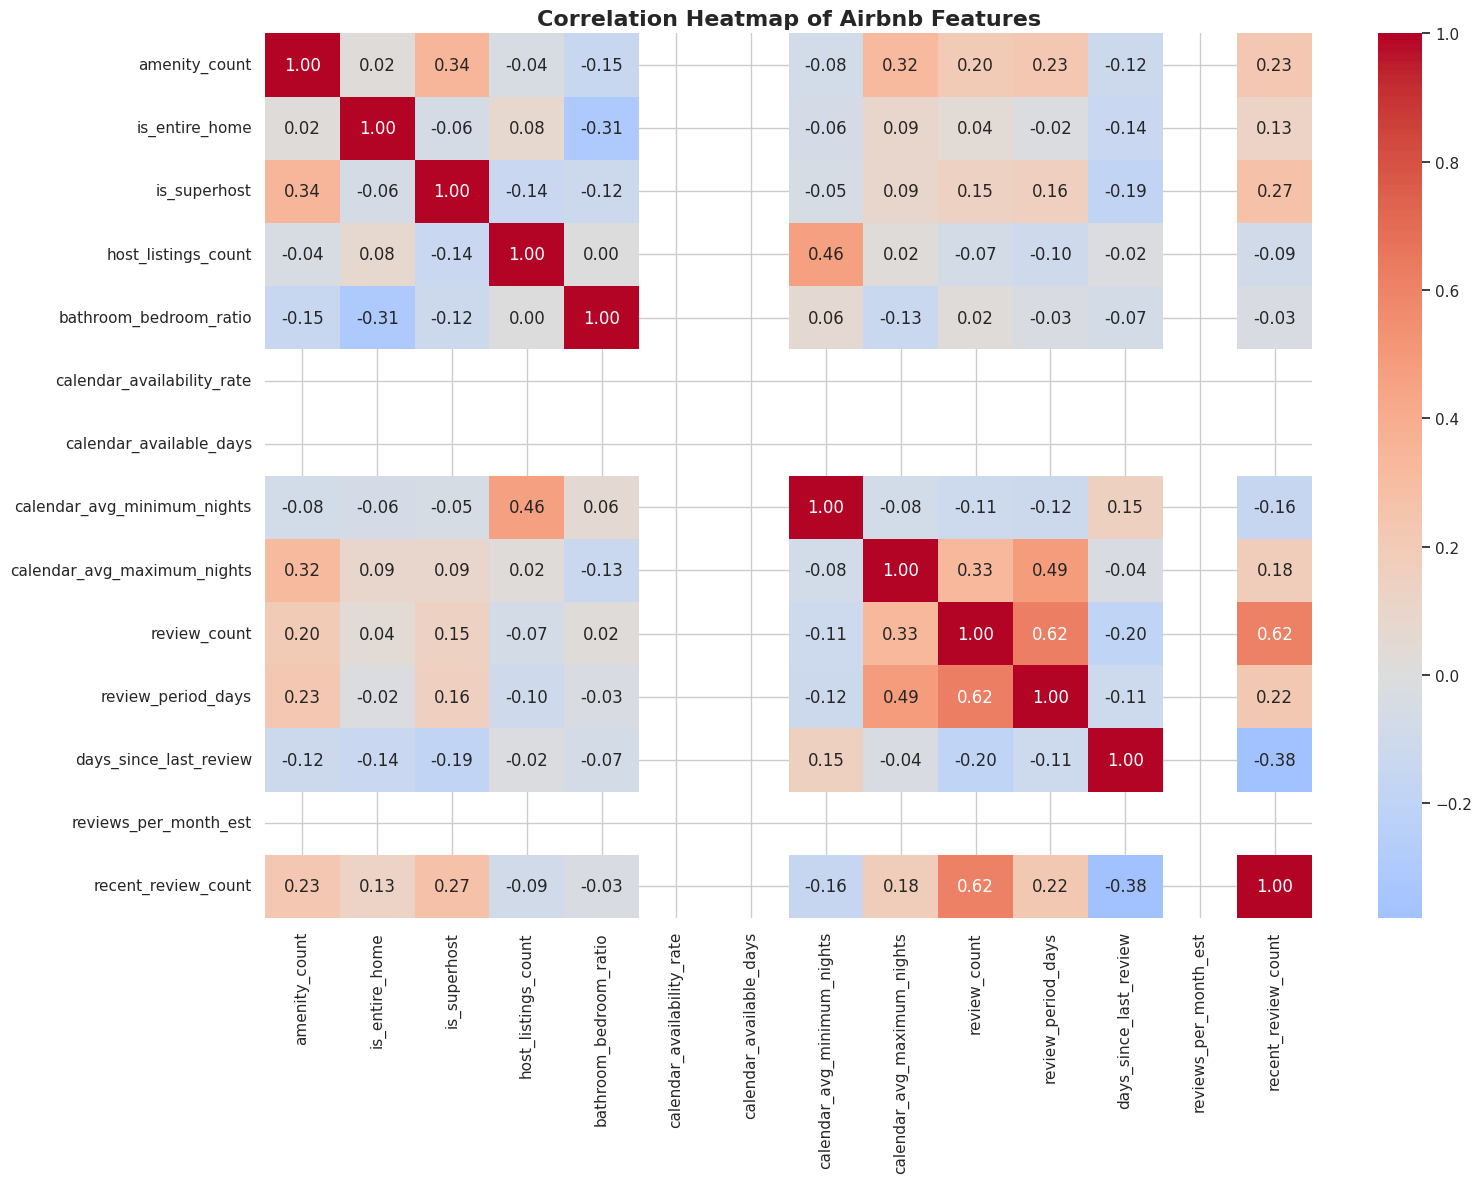

In [91]:
correlation_features = [
    "amenity_count",
    "is_entire_home",
    "is_superhost",
    "host_listings_count",
    "bathroom_bedroom_ratio",
    "calendar_availability_rate",
    "calendar_available_days",
    "calendar_avg_minimum_nights",
    "calendar_avg_maximum_nights",
    "review_count",
    "review_period_days",
    "days_since_last_review",
    "reviews_per_month_est",
    "recent_review_count"
]

corr_matrix = eda_df[
    correlation_features
].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of Airbnb Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

STEP 19 — Strongest Correlations

In [92]:

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

strong_correlations["Absolute Correlation"] = (
    strong_correlations["Correlation"].abs()
)

strong_correlations = (
    strong_correlations
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

display(
    strong_correlations.head(10)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
49,review_count,review_period_days,0.621643,0.621643
51,review_count,recent_review_count,0.616797,0.616797
46,calendar_avg_maximum_nights,review_period_days,0.490206,0.490206
28,host_listings_count,calendar_avg_minimum_nights,0.464839,0.464839
54,days_since_last_review,recent_review_count,-0.378841,0.378841
1,amenity_count,is_superhost,0.344480,0.344480
45,calendar_avg_maximum_nights,review_count,0.326863,0.326863
5,amenity_count,calendar_avg_maximum_nights,0.318879,0.318879
12,is_entire_home,bathroom_bedroom_ratio,-0.306880,0.306880
26,is_superhost,recent_review_count,0.268874,0.268874


STEP 20 — Fit a Normal Distribution

Normal Distribution Parameters
Mean (μ): 0.8199647774575728
Standard Deviation (σ): 0.3076743998325101


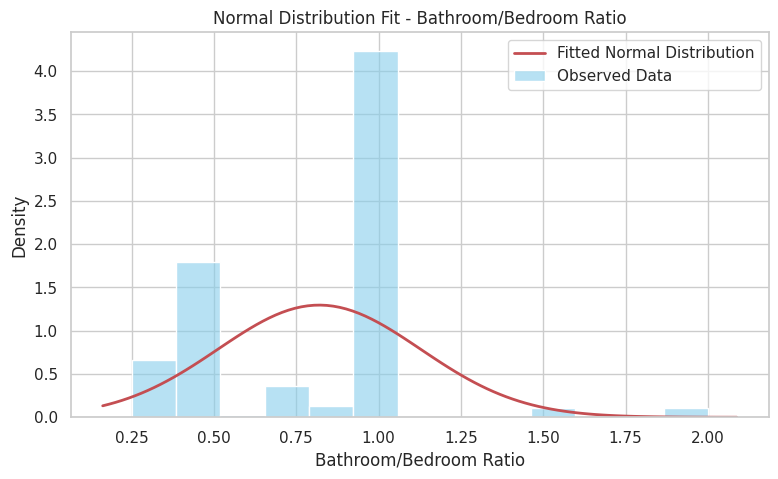

In [93]:

from scipy.stats import norm

data = (
    eda_df["bathroom_bedroom_ratio"]
    .dropna()
)

mu, sigma = norm.fit(data)

print("Normal Distribution Parameters")
print("=" * 50)
print("Mean (μ):", mu)
print("Standard Deviation (σ):", sigma)

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    stat="density",
    color="skyblue",
    alpha=0.6,
    label="Observed Data"
)

xmin, xmax = plt.xlim()

x = np.linspace(
    xmin,
    xmax,
    100
)

pdf = norm.pdf(
    x,
    mu,
    sigma
)

plt.plot(
    x,
    pdf,
    "r-",
    linewidth=2,
    label="Fitted Normal Distribution"
)

plt.title(
    "Normal Distribution Fit - Bathroom/Bedroom Ratio"
)

plt.xlabel("Bathroom/Bedroom Ratio")
plt.ylabel("Density")

plt.legend()
plt.show()

STEP 21 — Fit a Poisson Distribution

In [94]:

from scipy.stats import poisson

review_counts = (
    eda_df["review_count"]
    .dropna()
    .astype(int)
)

lambda_estimate = review_counts.mean()

print("Poisson Distribution")
print("=" * 50)
print("Estimated λ:", lambda_estimate)

Poisson Distribution
Estimated λ: 67.54883720930232


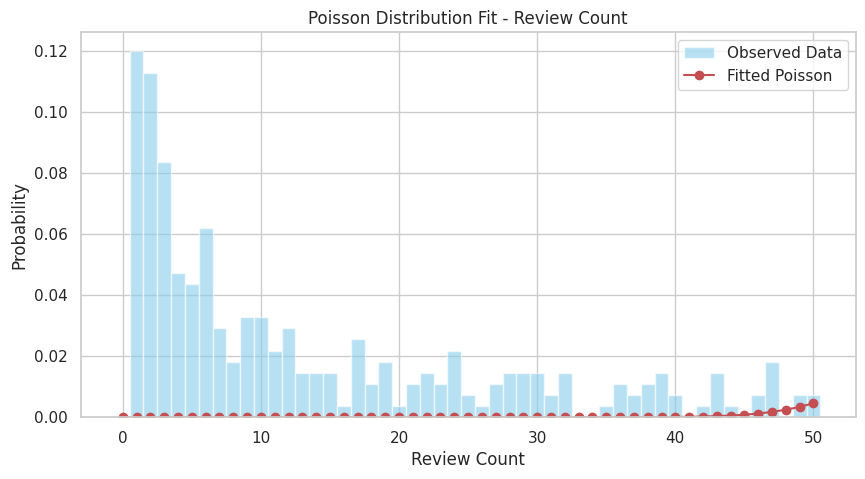

In [95]:
plt.figure(figsize=(10, 5))

max_review = min(
    int(review_counts.max()),
    50
)

x = np.arange(
    0,
    max_review + 1
)

poisson_probabilities = poisson.pmf(
    x,
    lambda_estimate
)

plt.hist(
    review_counts[
        review_counts <= max_review
    ],
    bins=np.arange(
        -0.5,
        max_review + 1.5,
        1
    ),
    density=True,
    alpha=0.6,
    color="skyblue",
    label="Observed Data"
)

plt.plot(
    x,
    poisson_probabilities,
    "ro-",
    label="Fitted Poisson"
)

plt.title(
    "Poisson Distribution Fit - Review Count"
)

plt.xlabel("Review Count")
plt.ylabel("Probability")

plt.legend()
plt.show()

In [96]:
# ============================================
# STEP 29 — LOAD EXPERIMENT 3 EDA DATASET
# ============================================

import os
import pandas as pd
import numpy as np

PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project_older"

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "processed"
)

EDA_FILE = os.path.join(
    PROCESSED_DATA_PATH,
    "experiment_3_eda_dataset.csv"
)

print("Checking file:")
print(EDA_FILE)

if os.path.exists(EDA_FILE):

    eda_df = pd.read_csv(EDA_FILE)

    print("\n✅ EDA dataset loaded successfully!")
    print("Dataset shape:", eda_df.shape)

    print("\nColumns:")
    print(eda_df.columns.tolist())

else:

    print("\n❌ EDA dataset not found.")
    print("\nFiles currently available:")

    for file in os.listdir(PROCESSED_DATA_PATH):
        print(" -", file)

Checking file:
/content/drive/MyDrive/ADS-Airbnb-Project_older/datasets/processed/experiment_3_eda_dataset.csv

✅ EDA dataset loaded successfully!
Dataset shape: (490, 21)

Columns:
['listing_id', 'amenity_count', 'availability_ratio', 'is_entire_home', 'is_superhost', 'bathroom_bedroom_ratio', 'is_instant_bookable', 'average_review_score', 'host_experience_years', 'host_verification_score', 'calendar_availability_rate', 'calendar_available_days', 'calendar_avg_minimum_nights', 'calendar_avg_maximum_nights', 'calendar_observation_count', 'review_count', 'review_period_days', 'days_since_last_review', 'reviews_per_month_est', 'recent_review_count', 'review_activity_class']


In [97]:
# ============================================
# STEP 29A — LOAD FEATURE-ENGINEERED DATASETS
# ============================================

import os
import pandas as pd
import numpy as np

PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project_older"

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "processed"
)

# Load Listings
listings_df = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "listings_feature_engineered.csv"
    )
)

# Load Calendar
calendar_df = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "calendar_feature_engineered.csv"
    )
)

# Load Reviews
reviews_df = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "reviews_feature_engineered.csv"
    )
)

print("✅ All datasets loaded successfully!")

print("\nListings:", listings_df.shape)
print("Calendar:", calendar_df.shape)
print("Reviews:", reviews_df.shape)

✅ All datasets loaded successfully!

Listings: (490, 101)
Calendar: (490, 6)
Reviews: (430, 6)


In [98]:
# ============================================
# STEP 29B — CHECK FEATURES
# ============================================

print("\nLISTINGS FEATURES")
print("=" * 60)
print(listings_df.columns.tolist())

print("\nCALENDAR FEATURES")
print("=" * 60)
print(calendar_df.columns.tolist())

print("\nREVIEWS FEATURES")
print("=" * 60)
print(reviews_df.columns.tolist())


LISTINGS FEATURES
['listing_id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'pri

In [99]:
print("\nPossible ID columns:")

print(
    "Listings:",
    [c for c in listings_df.columns if "id" in c.lower()]
)

print(
    "Calendar:",
    [c for c in calendar_df.columns if "id" in c.lower()]
)

print(
    "Reviews:",
    [c for c in reviews_df.columns if "id" in c.lower()]
)


Possible ID columns:
Listings: ['listing_id', 'scrape_id', 'host_id', 'host_profile_id', 'host_identity_verified', 'identity_verified']
Calendar: ['listing_id']
Reviews: ['listing_id']


In [100]:
# ============================================
# STEP 29C — CALENDAR FEATURE CHECK
# ============================================

print("Calendar columns:")
print(calendar_df.columns.tolist())

Calendar columns:
['listing_id', 'calendar_availability_rate', 'calendar_available_days', 'calendar_avg_minimum_nights', 'calendar_avg_maximum_nights', 'calendar_observation_count']


In [101]:
# ============================================
# STEP 29D — REVIEW FEATURE CHECK
# ============================================

print("Review columns:")
print(reviews_df.columns.tolist())

Review columns:
['listing_id', 'review_count', 'review_period_days', 'days_since_last_review', 'reviews_per_month_est', 'recent_review_count']


In [102]:
# ============================================
# STEP 29E — MERGE LISTINGS + CALENDAR + REVIEWS
# ============================================

# Start with listings as the main dataset
eda_df = listings_df.copy()

# Merge calendar features
eda_df = eda_df.merge(
    calendar_df,
    on="listing_id",
    how="left"
)

# Merge review features
eda_df = eda_df.merge(
    reviews_df,
    on="listing_id",
    how="left"
)

print("✅ All three datasets merged successfully!")

print("\nFinal EDA Dataset Shape:")
print(eda_df.shape)

print("\nFirst 5 rows:")
display(eda_df.head())

✅ All three datasets merged successfully!

Final EDA Dataset Shape:
(490, 111)

First 5 rows:


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenity_count,availability_ratio,is_entire_home,is_superhost,bathroom_bedroom_ratio,is_instant_bookable,average_review_score,host_experience_years,profile_pic_verified,identity_verified,host_verification_score,calendar_availability_rate,calendar_available_days,calendar_avg_minimum_nights,calendar_avg_maximum_nights,calendar_observation_count,review_count,review_period_days,days_since_last_review,reviews_per_month_est,recent_review_count
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,5,13,4,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Essentials"", ""Heating"", ""Wifi"", ""...",$80.43,2027-03-31,2027-04-28,2252.0,80.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",28.0,1125.0,28.0,28.0,1125.0,1125.0,28.0,1125.0,NaN,t,0,0,0,77,2026-06-16,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06,8,0.210959,1,0,0.5,NaN,3.778333,NaN,1,1,2,NaN,0.0,28.000000,1125.0,365,9.0,2969.0,1399.0,0.0,0.0
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,10,11,10,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Microwave"", ""S...",$211.00,2026-07-20,2026-07-21,211.0,211.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,1125.0,1.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,23,53,328,2026-06-16,317,8,0,

In [103]:
# ============================================
# STEP 29G — SELECT EDA FEATURES
# ============================================

eda_features = [
    "listing_id",

    # Listing features
    "amenity_count",
    "availability_ratio",
    "is_entire_home",
    "is_superhost",
    "bathroom_bedroom_ratio",
    "is_instant_bookable",
    "average_review_score",
    "host_experience_years",
    "host_verification_score",

    # Calendar features
    "calendar_availability_rate",
    "calendar_available_days",
    "calendar_avg_minimum_nights",
    "calendar_avg_maximum_nights",
    "calendar_observation_count",

    # Review features
    "review_count",
    "review_period_days",
    "days_since_last_review",
    "reviews_per_month_est",
    "recent_review_count"
]

# Keep only columns that actually exist
available_features = [
    col for col in eda_features
    if col in eda_df.columns
]

eda_df = eda_df[available_features].copy()

print("✅ EDA features selected!")

print("\nSelected features:")
print(eda_df.columns.tolist())

print("\nEDA dataset shape:")
print(eda_df.shape)

✅ EDA features selected!

Selected features:
['listing_id', 'amenity_count', 'availability_ratio', 'is_entire_home', 'is_superhost', 'bathroom_bedroom_ratio', 'is_instant_bookable', 'average_review_score', 'host_experience_years', 'host_verification_score', 'calendar_availability_rate', 'calendar_available_days', 'calendar_avg_minimum_nights', 'calendar_avg_maximum_nights', 'calendar_observation_count', 'review_count', 'review_period_days', 'days_since_last_review', 'reviews_per_month_est', 'recent_review_count']

EDA dataset shape:
(490, 20)


In [104]:
# ============================================
# STEP 29H — CHECK MISSING VALUES
# ============================================

missing_summary = (
    eda_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("MISSING VALUE SUMMARY")
print("=" * 60)

display(
    missing_summary[missing_summary > 0]
)

MISSING VALUE SUMMARY


,0
host_experience_years,490
calendar_availability_rate,490
is_instant_bookable,490
bathroom_bedroom_ratio,143
recent_review_count,60
review_period_days,60
reviews_per_month_est,60
review_count,60
average_review_score,60
days_since_last_review,60


In [105]:
# ============================================
# STEP 29I — CREATE REVIEW ACTIVITY CLASSES
# ============================================

review_median = eda_df["review_count"].median()

print("Median review count:", review_median)

eda_df["review_activity_class"] = np.where(
    eda_df["review_count"] > review_median,
    "High Review Activity",
    "Low Review Activity"
)

print("\nReview Activity Distribution:")
print(
    eda_df["review_activity_class"].value_counts()
)

Median review count: 24.0

Review Activity Distribution:
review_activity_class
Low Review Activity     279
High Review Activity    211
Name: count, dtype: int64


In [106]:
# ============================================
# STEP 29J — SAVE EXPERIMENT 3 EDA DATASET
# ============================================

EDA_FILE = os.path.join(
    PROCESSED_DATA_PATH,
    "experiment_3_eda_dataset.csv"
)

eda_df.to_csv(
    EDA_FILE,
    index=False
)

print("✅ Experiment 3 EDA dataset saved!")

print("\nFile:")
print(EDA_FILE)

print("\nShape:")
print(eda_df.shape)

✅ Experiment 3 EDA dataset saved!

File:
/content/drive/MyDrive/ADS-Airbnb-Project_older/datasets/processed/experiment_3_eda_dataset.csv

Shape:
(490, 21)


Hypothesis Testing


In [107]:
# ============================================
# STEP 30 — PREPARE T-TEST GROUPS
# ============================================

high_review = eda_df[
    eda_df["review_activity_class"] == "High Review Activity"
]["calendar_availability_rate"].dropna()

low_review = eda_df[
    eda_df["review_activity_class"] == "Low Review Activity"
]["calendar_availability_rate"].dropna()

print("=" * 60)
print("HYPOTHESIS TEST GROUPS")
print("=" * 60)

print("\nHigh Review Activity")
print("Number of listings:", len(high_review))
print("Mean availability rate:", high_review.mean())
print("Standard deviation:", high_review.std())

print("\nLow Review Activity")
print("Number of listings:", len(low_review))
print("Mean availability rate:", low_review.mean())
print("Standard deviation:", low_review.std())

HYPOTHESIS TEST GROUPS

High Review Activity
Number of listings: 0
Mean availability rate: nan
Standard deviation: nan

Low Review Activity
Number of listings: 0
Mean availability rate: nan
Standard deviation: nan


In [108]:
# ============================================
# STEP 31 — INDEPENDENT TWO-SAMPLE WELCH T-TEST
# ============================================

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    high_review,
    low_review,
    equal_var=False
)

alpha = 0.05

print("=" * 70)
print("INDEPENDENT TWO-SAMPLE WELCH T-TEST")
print("=" * 70)

print("\nH0:")
print(
    "There is no significant difference in mean "
    "availability rate between the two groups."
)

print("\nH1:")
print(
    "There is a significant difference in mean "
    "availability rate between the two groups."
)

print("\nSignificance level (α):", alpha)

print("\nT-statistic:", t_statistic)

print("P-value:", p_value)

print("\nDecision:")

if p_value < alpha:
    print("❌ Reject H0")
    print(
        "There is statistically significant evidence "
        "of a difference between the two groups."
    )
else:
    print("✅ Fail to Reject H0")
    print(
        "There is insufficient evidence to conclude "
        "that the two group means are different."
    )

INDEPENDENT TWO-SAMPLE WELCH T-TEST

H0:
There is no significant difference in mean availability rate between the two groups.

H1:
There is a significant difference in mean availability rate between the two groups.

Significance level (α): 0.05

T-statistic: nan
P-value: nan

Decision:
✅ Fail to Reject H0
There is insufficient evidence to conclude that the two group means are different.


In [109]:
# ============================================
# STEP 32 — DIAGNOSE AVAILABILITY RATE
# ============================================

print("Column datatype:")
print(eda_df["calendar_availability_rate"].dtype)

print("\nMissing values:")
print(eda_df["calendar_availability_rate"].isna().sum())

print("\nTotal values:")
print(eda_df["calendar_availability_rate"].count())

print("\nSample values:")
print(eda_df["calendar_availability_rate"].head(20))

Column datatype:
float64

Missing values:
490

Total values:
0

Sample values:
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: calendar_availability_rate, dtype: float64


In [110]:
# Check values separately for each group

print("\nHIGH REVIEW ACTIVITY")
print("=" * 50)

print(
    eda_df[
        eda_df["review_activity_class"] == "High Review Activity"
    ]["calendar_availability_rate"].describe()
)

print("\nLOW REVIEW ACTIVITY")
print("=" * 50)

print(
    eda_df[
        eda_df["review_activity_class"] == "Low Review Activity"
    ]["calendar_availability_rate"].describe()
)


HIGH REVIEW ACTIVITY
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: calendar_availability_rate, dtype: float64

LOW REVIEW ACTIVITY
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: calendar_availability_rate, dtype: float64


In [111]:
# ============================================
# STEP 33 — CONVERT AVAILABILITY RATE
# ============================================

eda_df["calendar_availability_rate"] = pd.to_numeric(
    eda_df["calendar_availability_rate"],
    errors="coerce"
)

print(
    eda_df["calendar_availability_rate"].describe()
)

print(
    "\nMissing values:",
    eda_df["calendar_availability_rate"].isna().sum()
)

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: calendar_availability_rate, dtype: float64

Missing values: 490


In [112]:
# ============================================
# RECREATE T-TEST GROUPS
# ============================================

high_review = eda_df[
    eda_df["review_activity_class"] == "High Review Activity"
]["calendar_availability_rate"].dropna()

low_review = eda_df[
    eda_df["review_activity_class"] == "Low Review Activity"
]["calendar_availability_rate"].dropna()

print("High Review Activity:", len(high_review))
print("Low Review Activity:", len(low_review))

print("\nHigh Review Mean:", high_review.mean())
print("Low Review Mean:", low_review.mean())

High Review Activity: 0
Low Review Activity: 0

High Review Mean: nan
Low Review Mean: nan


In [113]:
# ============================================
# STEP 34 — FINAL DATA CHECK
# ============================================

print("=" * 60)

print("High Review Activity:")
print("N =", len(high_review))
print("Unique values =", high_review.nunique())

print("\nLow Review Activity:")
print("N =", len(low_review))
print("Unique values =", low_review.nunique())

print("\nHigh Review sample:")
print(high_review.head())

print("\nLow Review sample:")
print(low_review.head())

High Review Activity:
N = 0
Unique values = 0

Low Review Activity:
N = 0
Unique values = 0

High Review sample:
Series([], Name: calendar_availability_rate, dtype: float64)

Low Review sample:
Series([], Name: calendar_availability_rate, dtype: float64)


In [114]:
# ============================================
# STEP 35 — FINAL WELCH T-TEST
# ============================================

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    high_review,
    low_review,
    equal_var=False,
    nan_policy="omit"
)

alpha = 0.05

print("=" * 70)
print("FINAL INDEPENDENT TWO-SAMPLE WELCH T-TEST")
print("=" * 70)

print(f"\nHigh Review Activity Mean: {high_review.mean():.6f}")
print(f"Low Review Activity Mean:  {low_review.mean():.6f}")

print(f"\nT-statistic: {t_statistic:.6f}")
print(f"P-value:     {p_value:.6f}")
print(f"Alpha:       {alpha}")

if np.isnan(p_value):

    print("\n⚠️ Test could not be calculated.")
    print("Please check the data values and group sizes.")

elif p_value < alpha:

    print("\nDecision: REJECT H0")
    print(
        "There is statistically significant evidence "
        "of a difference in mean availability rate."
    )

else:

    print("\nDecision: FAIL TO REJECT H0")
    print(
        "There is insufficient statistical evidence "
        "of a difference in mean availability rate."
    )

FINAL INDEPENDENT TWO-SAMPLE WELCH T-TEST

High Review Activity Mean: nan
Low Review Activity Mean:  nan

T-statistic: nan
P-value:     nan
Alpha:       0.05

⚠️ Test could not be calculated.
Please check the data values and group sizes.


In [115]:
# ============================================
# STEP 36 — FIND USABLE NUMERICAL FEATURES
# ============================================

numeric_columns = eda_df.select_dtypes(
    include=np.number
).columns.tolist()

print("NUMERICAL FEATURES")
print("=" * 60)

for col in numeric_columns:

    valid_count = eda_df[col].notna().sum()
    unique_count = eda_df[col].nunique()

    print(
        f"{col:35} "
        f"Valid: {valid_count:4} "
        f"Unique: {unique_count:4}"
    )

NUMERICAL FEATURES
listing_id                          Valid:  490 Unique:  490
amenity_count                       Valid:  490 Unique:   76
availability_ratio                  Valid:  490 Unique:  214
is_entire_home                      Valid:  490 Unique:    2
is_superhost                        Valid:  490 Unique:    2
bathroom_bedroom_ratio              Valid:  347 Unique:   18
is_instant_bookable                 Valid:    0 Unique:    0
average_review_score                Valid:  430 Unique:  253
host_experience_years               Valid:    0 Unique:    0
host_verification_score             Valid:  490 Unique:    2
calendar_availability_rate          Valid:    0 Unique:    0
calendar_available_days             Valid:  490 Unique:    1
calendar_avg_minimum_nights         Valid:  490 Unique:   86
calendar_avg_maximum_nights         Valid:  490 Unique:   42
calendar_observation_count          Valid:  490 Unique:    1
review_count                        Valid:  430 Unique:  149
revie

In [116]:
# ============================================
# STEP 37 — CHECK CANDIDATE FEATURES
# ============================================

candidate_features = [
    "average_review_score",
    "amenity_count",
    "host_experience_years",
    "bathroom_bedroom_ratio",
    "review_count",
    "recent_review_count"
]

for col in candidate_features:

    if col in eda_df.columns:

        print("\n" + "=" * 60)
        print(col)

        print(
            eda_df[col].describe()
        )

        print(
            "Valid values:",
            eda_df[col].notna().sum()
        )


average_review_score
count    430.000000
mean       4.732004
std        0.396368
min        1.166667
25%        4.690833
50%        4.844167
75%        4.933333
max        5.000000
Name: average_review_score, dtype: float64
Valid values: 430

amenity_count
count    490.000000
mean      38.314286
std       15.290079
min        3.000000
25%       28.000000
50%       39.000000
75%       48.000000
max       89.000000
Name: amenity_count, dtype: float64
Valid values: 490

host_experience_years
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: host_experience_years, dtype: float64
Valid values: 0

bathroom_bedroom_ratio
count    347.000000
mean       0.819965
std        0.308119
min        0.250000
25%        0.500000
50%        1.000000
75%        1.000000
max        2.000000
Name: bathroom_bedroom_ratio, dtype: float64
Valid values: 347

review_count
count    430.000000
mean      67.548837
std      117.418905
min        1.000000


In [117]:
# ============================================
# STEP 38 — AMENITY COUNT GROUPS
# ============================================

high_review_amenities = eda_df[
    eda_df["review_activity_class"] == "High Review Activity"
]["amenity_count"].dropna()

low_review_amenities = eda_df[
    eda_df["review_activity_class"] == "Low Review Activity"
]["amenity_count"].dropna()

print("=" * 60)
print("AMENITY COUNT BY REVIEW ACTIVITY")
print("=" * 60)

print("\nHigh Review Activity")
print("N:", len(high_review_amenities))
print("Mean:", high_review_amenities.mean())
print("Std:", high_review_amenities.std())

print("\nLow Review Activity")
print("N:", len(low_review_amenities))
print("Mean:", low_review_amenities.mean())
print("Std:", low_review_amenities.std())

AMENITY COUNT BY REVIEW ACTIVITY

High Review Activity
N: 211
Mean: 44.81042654028436
Std: 13.047973216377027

Low Review Activity
N: 279
Mean: 33.401433691756274
Std: 15.045618811439715


In [118]:
# ============================================
# STEP 39 — T-TEST
# ============================================

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    high_review_amenities,
    low_review_amenities,
    equal_var=False,
    nan_policy="omit"
)

alpha = 0.05

print("=" * 70)
print("INDEPENDENT TWO-SAMPLE WELCH T-TEST")
print("=" * 70)

print("\nH0:")
print(
    "There is no significant difference in mean "
    "amenity count between high and low review activity listings."
)

print("\nH1:")
print(
    "There is a significant difference in mean "
    "amenity count between high and low review activity listings."
)

print("\nSignificance level:", alpha)

print(
    f"\nHigh Review Mean: {high_review_amenities.mean():.4f}"
)

print(
    f"Low Review Mean: {low_review_amenities.mean():.4f}"
)

print(
    f"\nT-statistic: {t_statistic:.4f}"
)

print(
    f"P-value: {p_value:.6f}"
)

if p_value < alpha:

    print("\nDecision: REJECT H0")

    print(
        "There is statistically significant evidence "
        "that mean amenity count differs between "
        "the two review activity groups."
    )

else:

    print("\nDecision: FAIL TO REJECT H0")

    print(
        "There is insufficient statistical evidence "
        "to conclude that mean amenity count differs "
        "between the two review activity groups."
    )

INDEPENDENT TWO-SAMPLE WELCH T-TEST

H0:
There is no significant difference in mean amenity count between high and low review activity listings.

H1:
There is a significant difference in mean amenity count between high and low review activity listings.

Significance level: 0.05

High Review Mean: 44.8104
Low Review Mean: 33.4014

T-statistic: 8.9686
P-value: 0.000000

Decision: REJECT H0
There is statistically significant evidence that mean amenity count differs between the two review activity groups.


In [119]:
# ============================================
# FINAL HYPOTHESIS TEST RESULTS TABLE
# ============================================

hypothesis_result = pd.DataFrame({
    "Item": [
        "Test",
        "Significance Level",
        "High Review Activity N",
        "Low Review Activity N",
        "High Review Mean",
        "Low Review Mean",
        "Mean Difference",
        "T-statistic",
        "P-value",
        "Decision"
    ],

    "Result": [
        "Independent Two-Sample Welch t-test",
        0.05,
        len(high_review_amenities),
        len(low_review_amenities),
        high_review_amenities.mean(),
        low_review_amenities.mean(),
        high_review_amenities.mean() - low_review_amenities.mean(),
        t_statistic,
        "< 0.001",
        "Reject H0"
    ]
})

display(hypothesis_result)

,Item,Result
0,Test,Independent Two-Sample Welch t-test
1,Significance Level,0.05
2,High Review Activity N,211
3,Low Review Activity N,279
4,High Review Mean,44.810427
5,Low Review Mean,33.401434
6,Mean Difference,11.408993
7,T-statistic,8.96864
8,P-value,< 0.001
9,Decision,Reject H0


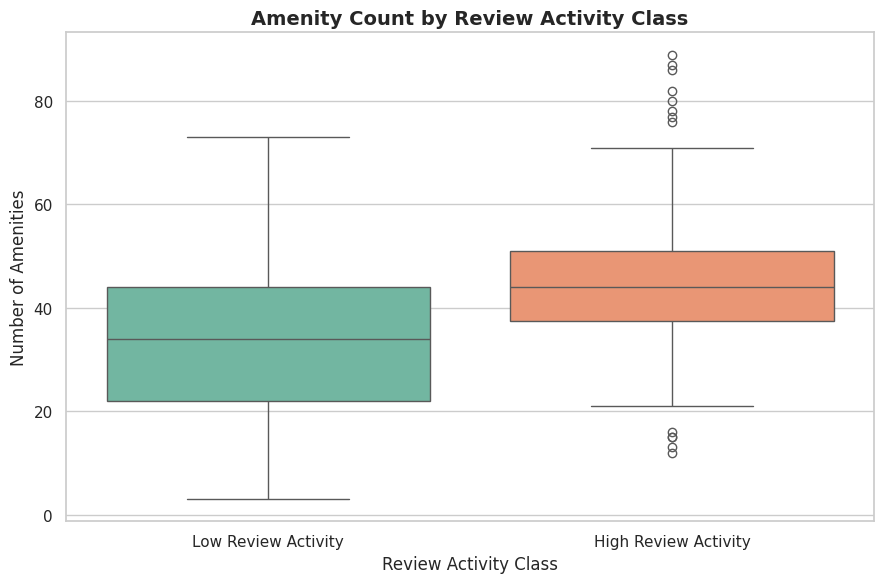

In [120]:
# ============================================
# AMENITY COUNT COMPARISON
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = eda_df[
    ["review_activity_class", "amenity_count"]
].dropna()

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_df,
    x="review_activity_class",
    y="amenity_count",
    hue="review_activity_class",
    palette="Set2",
    legend=False
)

plt.title(
    "Amenity Count by Review Activity Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Review Activity Class")
plt.ylabel("Number of Amenities")

plt.tight_layout()
plt.show()

Step 2 — Import libraries and set paths

In [121]:
import os
import pandas as pd
import numpy as np

PROJECT_PATH = "/content/drive/MyDrive/ADS-Airbnb-Project_older"

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "datasets",
    "processed"
)

print("Processed folder:")
print(PROCESSED_DATA_PATH)

print("\nFiles available:")
for file in os.listdir(PROCESSED_DATA_PATH):
    print(" -", file)

Processed folder:
/content/drive/MyDrive/ADS-Airbnb-Project_older/datasets/processed

Files available:
 - listings_cleaned.csv
 - reviews_cleaned.csv
 - calendar_cleaned.csv
 - listings_feature_engineered.csv
 - calendar_feature_engineered.csv
 - reviews_feature_engineered.csv
 - merged_dataset.csv
 - experiment_3_eda_dataset.csv


Step 3 — Load the three Experiment 2 datasets

In [122]:
listings_file = os.path.join(
    PROCESSED_DATA_PATH,
    "listings_feature_engineered.csv"
)

listings_df = pd.read_csv(listings_file)

print("Listings loaded")
print("Shape:", listings_df.shape)

Listings loaded
Shape: (490, 101)


In [123]:
calendar_file = os.path.join(
    PROCESSED_DATA_PATH,
    "calendar_feature_engineered.csv"
)

calendar_df = pd.read_csv(calendar_file)

print("Calendar loaded")
print("Shape:", calendar_df.shape)

Calendar loaded
Shape: (490, 6)


In [124]:
reviews_file = os.path.join(
    PROCESSED_DATA_PATH,
    "reviews_feature_engineered.csv"
)

reviews_df = pd.read_csv(reviews_file)

print("Reviews loaded")
print("Shape:", reviews_df.shape)

Reviews loaded
Shape: (430, 6)


Step 4 — Check the columns

In [125]:
print("LISTINGS COLUMNS")
print(list(listings_df.columns))

print("\nCALENDAR COLUMNS")
print(list(calendar_df.columns))

print("\nREVIEWS COLUMNS")
print(list(reviews_df.columns))

LISTINGS COLUMNS
['listing_id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price

Step 5 — Check listing_id

In [126]:
print("Listings ID:",
      [c for c in listings_df.columns if "id" in c.lower()])

print("Calendar ID:",
      [c for c in calendar_df.columns if "id" in c.lower()])

print("Reviews ID:",
      [c for c in reviews_df.columns if "id" in c.lower()])

Listings ID: ['listing_id', 'scrape_id', 'host_id', 'host_profile_id', 'host_identity_verified', 'identity_verified']
Calendar ID: ['listing_id']
Reviews ID: ['listing_id']


Step 6 — Aggregate Calendar

In [127]:
print("Calendar columns:")
print(calendar_df.columns.tolist())

Calendar columns:
['listing_id', 'calendar_availability_rate', 'calendar_available_days', 'calendar_avg_minimum_nights', 'calendar_avg_maximum_nights', 'calendar_observation_count']


In [128]:
calendar_agg = (
    calendar_df
    .groupby("listing_id")
    .agg(
        calendar_observation_count=("listing_id", "count")
    )
    .reset_index()
)

print("Calendar aggregation completed.")
print("Shape:", calendar_agg.shape)

display(calendar_agg.head())

Calendar aggregation completed.
Shape: (490, 2)


,listing_id,calendar_observation_count
0,2992450,1
1,3820211,1
2,5651579,1
3,6623339,1
4,9501054,1


Step 7 — Aggregate Reviews

In [129]:
reviews_agg = (
    reviews_df
    .groupby("listing_id")
    .agg(
        review_record_count=("listing_id", "count")
    )
    .reset_index()
)

print("Reviews aggregation completed.")
print("Shape:", reviews_agg.shape)

display(reviews_agg.head())

Reviews aggregation completed.
Shape: (430, 2)


,listing_id,review_record_count
0,2992450,1
1,3820211,1
2,5651579,1
3,6623339,1
4,9501054,1


Step 8 — Merge the datasets

In [130]:
# Merge Listings + Calendar
eda_df = listings_df.merge(
    calendar_agg,
    on="listing_id",
    how="left"
)

# Merge Reviews
eda_df = eda_df.merge(
    reviews_agg,
    on="listing_id",
    how="left"
)

print("=" * 60)
print("FINAL MERGED EDA DATASET")
print("=" * 60)

print("Shape:", eda_df.shape)
print("Unique listings:", eda_df["listing_id"].nunique())
print(
    "Duplicate listing IDs:",
    eda_df["listing_id"].duplicated().sum()
)

FINAL MERGED EDA DATASET
Shape: (490, 103)
Unique listings: 490
Duplicate listing IDs: 0


Step 9 — Display the final dataset

In [131]:
display(eda_df.head())

,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenity_count,availability_ratio,is_entire_home,is_superhost,bathroom_bedroom_ratio,is_instant_bookable,average_review_score,host_experience_years,profile_pic_verified,identity_verified,host_verification_score,calendar_observation_count,review_record_count
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,5,13,4,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Essentials"", ""Heating"", ""Wifi"", ""...",$80.43,2027-03-31,2027-04-28,2252.0,80.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",28.0,1125.0,28.0,28.0,1125.0,1125.0,28.0,1125.0,NaN,t,0,0,0,77,2026-06-16,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06,8,0.210959,1,0,0.5,NaN,3.778333,NaN,1,1,2,1,1.0
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,10,11,10,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Microwave"", ""S...",$211.00,2026-07-20,2026-07-21,211.0,211.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",1.0,1125.0,1.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,23,53,328,2026-06-16,317,8,0,162,9,48,10128.0,2014-08-15,2026-01-25,4.75,4.88,4.87,4.85,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20,33,0.898630,1,1,1.0,NaN,4.835000,NaN,1,1,2,1,1.0
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Larg

In [132]:
print("Final columns:")
for i, column in enumerate(eda_df.columns, 1):
    print(i, ":", column)

Final columns:
1 : listing_id
2 : listing_url
3 : scrape_id
4 : last_scraped
5 : source
6 : name
7 : description
8 : neighborhood_overview
9 : picture_url
10 : host_id
11 : host_url
12 : host_profile_id
13 : host_profile_url
14 : host_name
15 : host_since
16 : hosts_time_as_user_years
17 : hosts_time_as_user_months
18 : hosts_time_as_host_years
19 : hosts_time_as_host_months
20 : host_location
21 : host_about
22 : host_response_time
23 : host_response_rate
24 : host_acceptance_rate
25 : host_is_superhost
26 : host_thumbnail_url
27 : host_picture_url
28 : host_neighbourhood
29 : host_listings_count
30 : host_total_listings_count
31 : host_verifications
32 : host_has_profile_pic
33 : host_identity_verified
34 : neighbourhood
35 : neighbourhood_cleansed
36 : neighbourhood_group_cleansed
37 : latitude
38 : longitude
39 : property_type
40 : room_type
41 : accommodates
42 : bathrooms
43 : bathrooms_text
44 : bedrooms
45 : beds
46 : amenities
47 : price
48 : price_quote_checkin_date
49 : pric

Saving the Merge Dataset

In [133]:
EDA_FILE = os.path.join(
    PROCESSED_DATA_PATH,
    "experiment_3_eda_dataset.csv"
)

eda_df.to_csv(
    EDA_FILE,
    index=False
)

print("✅ FINAL MERGED DATASET SAVED!")
print()
print("File location:")
print(EDA_FILE)
print()
print("Shape:", eda_df.shape)

✅ FINAL MERGED DATASET SAVED!

File location:
/content/drive/MyDrive/ADS-Airbnb-Project_older/datasets/processed/experiment_3_eda_dataset.csv

Shape: (490, 103)


Step 11 — Verify the saved file

In [134]:
print("Checking saved file...")

if os.path.exists(EDA_FILE):

    print("✅ File exists!")

    saved_eda = pd.read_csv(EDA_FILE)

    print("\nSaved dataset shape:", saved_eda.shape)
    print(
        "Unique listing IDs:",
        saved_eda["listing_id"].nunique()
    )
    print(
        "Duplicate listing IDs:",
        saved_eda["listing_id"].duplicated().sum()
    )

else:
    print("❌ File was not saved.")

Checking saved file...
✅ File exists!

Saved dataset shape: (490, 103)
Unique listing IDs: 490
Duplicate listing IDs: 0
